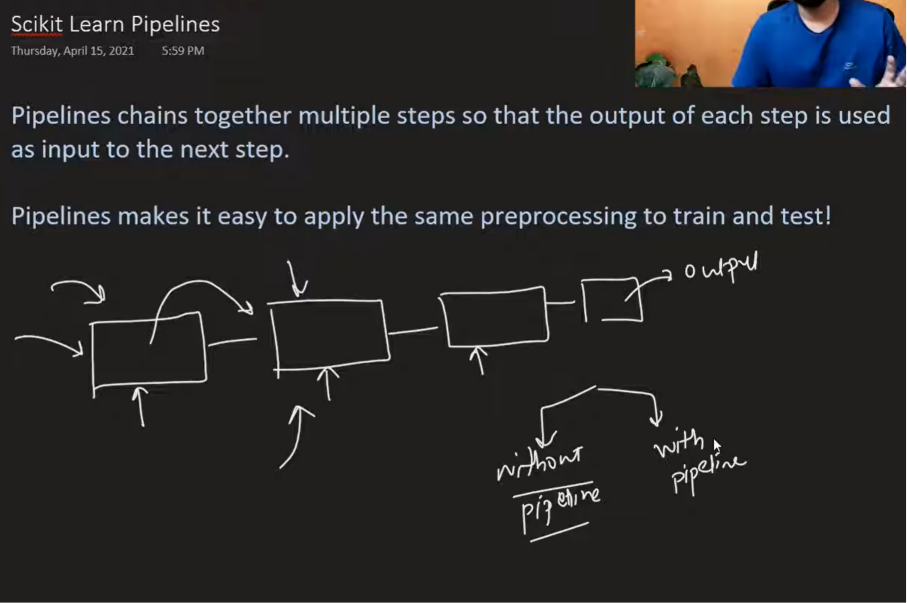

# Wihtout Pipelining

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer




In [2]:

df=pd.read_csv('dataset/Titanic-Dataset.csv')

In [3]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [4]:
df.shape

(891, 12)

here `passengerid` , `name` ,`ticket`,`cabin`  is not so important to predict 

In [5]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

In [6]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [7]:
# finding missing values
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [8]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Survived',axis=1),
                                               df['Survived'],
                                               test_size=0.2,
                                               random_state=42
                                               
                                               )

In [9]:
x_train.sample(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
573,3,female,NaN,0,0,7.7500,Q
74,3,male,32.0,0,0,56.4958,S


In [10]:
# lets fill age and embarked missign vlaues
# apply imputer

si_age=SimpleImputer()
si_embarked=SimpleImputer(strategy='most_frequent')

x_train_age=si_age.fit_transform(x_train[['Age']])
x_train_embarked=si_embarked.fit_transform(x_train[['Embarked']])

# for test

x_test_age=si_age.transform(x_test[['Age']])
x_test_embarked=si_embarked.transform(x_test[['Embarked']])




In [11]:
# lets check does any value is mising in embarked or age
np.isnan(x_train_age).sum()

np.int64(0)

apply OneHotEncoder on sex and embarked

In [12]:
ohe_sex=OneHotEncoder(sparse_output=False,handle_unknown='ignore')  # when any iput is given in which any addition category fall then handle_unkown ignore this means it puts 0 for all

# here we not use drop because it doesnot cause multicollineary problem
ohe_embarked=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
# here we dont use drop ='first' because here we will going to use deicsion tree algo which does not affected by multicollinaerty



x_train_sex=ohe_sex.fit_transform(x_train[['Sex']])
x_train_embarked=ohe_embarked.fit_transform(x_train_embarked)


x_test_sex=ohe_sex.transform(x_test[['Sex']])
x_test_embarked=ohe_embarked.transform(x_test_embarked)


x_test_embarked



array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0

In [13]:
x_train.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [14]:
x_train_rem=x_train.drop(columns=['Sex','Age','Embarked'])

In [15]:
x_test_rem=x_test.drop(columns=['Sex','Age','Embarked'])

In [16]:
x_test_rem

,Pclass,SibSp,Parch,Fare
709,3,1,1,15.2458
439,2,0,0,10.5000
840,3,0,0,7.9250
720,2,0,1,33.0000
39,3,1,0,11.2417
...,...,...,...,...
433,3,0,0,7.1250
773,3,0,0,7.2250
25,3,1,5,31.3875
84,2,0,0,10.5000


In [17]:
### now transformation

x_train_transformed=np.concatenate((x_train_rem,x_train_age,x_train_embarked,x_train_sex),axis=1)


x_test_transformed=np.concatenate((x_test_rem,x_test_age,x_test_embarked,x_test_sex),axis=1)


In [18]:
from sklearn.tree import DecisionTreeClassifier

clf=DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred=clf.predict(x_test_transformed)

In [20]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))

0.776536312849162


#### now if we want to deploy our model  or save our model then we have to also save the imputer , ohe because our model trained on number but when user gives input then it may be string so it need to encoding so that our model can predict

In [21]:
import pickle

pickle.dump(ohe_embarked,open('model/ohe_embarked.pkl','wb'))
pickle.dump(ohe_sex,open('model/ohe_sex.pkl','wb'))
pickle.dump(clf,open('model/clf.pkl','wb'))